# 03 - Model Evaluation

Reproduces Table 2 (Peru-wide and validation-region overlap/AUC for all five models) and the per-glacier analysis figures: overlap histogram and vulnerability characteristics.

All logic lives in `glacier_melt.evaluate` and `glacier_melt.visualise`; this notebook only loads predictions, calls those functions, and displays results.

In [1]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from glacier_melt.sampling import load_parquet_regions, LABEL_COL
from glacier_melt.evaluate import (
    evaluate_model, print_summary_table,
    assign_pixels_to_glaciers, per_glacier_metrics,
    glacier_physical_features, vulnerability_ranking,
)
from glacier_melt.visualise import (
    plot_overlap_histogram, plot_vulnerability_characteristics,
)

PREDICTIONS_DIR = Path("../data/Predictions")
TRAINING_DIR = Path("../data/Training_Data_2017")
RGI_PATH = Path("../data/rgi70_peru.geojson")
OUTPUT_DIR = Path("../results")
OUTPUT_DIR.mkdir(exist_ok=True)

VALIDATION_REGION = "r3"

# Actual prediction column names (predictions_full_peru_r3holdout.parquet)
MODEL_COLS = {
    "RF (EASD)":    "prob_rf_easd",
    "RF (AE)":      "prob_rf_ae64",
    "MLP (AE)":     "prob_mlp_ae64",
    "CNN 3x3 (AE)": "prob_cnn_patch3",
    "CNN 5x5 (AE)": "prob_cnn5_patch5",
}
MLP_COL = MODEL_COLS["MLP (AE)"]

## Load predictions and RGI polygons

In [2]:
df = pd.read_parquet(
    PREDICTIONS_DIR / "predictions_full_peru_r3holdout.parquet"
)
rgi_gdf = gpd.read_file(RGI_PATH)

region_mask = (df["region"] == VALIDATION_REGION).values
print(f"Loaded {len(df):,} pixels, {region_mask.sum():,} in validation region")
print(f"Columns: {df.columns.tolist()}")

Loaded 13,996,828 pixels, 1,774,319 in validation region
Columns: ['lon', 'lat', 'melt_label', 'edge_distance', 'region', 'prob_rf_easd', 'prob_mlp_ae64', 'prob_cnn_patch3', 'prob_cnn5_patch5', 'prob_rf_ae64']


## Table 2 - Peru-wide and validation metrics for all models

In [6]:
results = {}
for name, col in MODEL_COLS.items():
    results[name] = evaluate_model(
        df[col].values, df[LABEL_COL].values,
        region_mask=region_mask, model_name=name,
    )

print_summary_table(results)

RF (EASD): Peru-wide: overlap=77.82%, IoU=0.6369, AUC=0.9528
RF (EASD): Val (R3):  overlap=70.29%, IoU=0.5418, AUC=0.8987
RF (AE): Peru-wide: overlap=83.65%, IoU=0.7190, AUC=0.9734
RF (AE): Val (R3):  overlap=68.36%, IoU=0.5193, AUC=0.8839
MLP (AE): Peru-wide: overlap=81.10%, IoU=0.6821, AUC=0.9698
MLP (AE): Val (R3):  overlap=79.52%, IoU=0.6600, AUC=0.9454
CNN 3x3 (AE): Peru-wide: overlap=84.54%, IoU=0.7322, AUC=0.9773
CNN 3x3 (AE): Val (R3):  overlap=79.85%, IoU=0.6646, AUC=0.9451
CNN 5x5 (AE): Peru-wide: overlap=84.42%, IoU=0.7303, AUC=0.9717
CNN 5x5 (AE): Val (R3):  overlap=73.37%, IoU=0.5795, AUC=0.9160

Model                Peru Overlap  Peru AUC  Val Overlap   Val AUC
------------------------------------------------------------------
RF (EASD)                  77.82%    0.9528       70.29%    0.8987
RF (AE)                    83.65%    0.9734       68.36%    0.8839
MLP (AE)                   81.10%    0.9698       79.52%    0.9454
CNN 3x3 (AE)               84.54%    0.9773     

## Per-glacier analysis (selected model: MLP)

Assigns pixels to RGI glaciers and computes per-glacier overlap using the MLP predicted probabilities.

In [7]:
df["rgi_id"] = assign_pixels_to_glaciers(df, rgi_gdf)

df_overlap = per_glacier_metrics(
    df, df[MLP_COL].values, min_area_km2=0.1,
)
df_overlap.to_parquet(OUTPUT_DIR / "per_glacier_overlap.parquet", index=False)

Per-glacier metrics: 1,342 glaciers
Mean overlap: 78.80%
Median overlap: 80.29%


### Overlap histogram - train vs validation regions

Glaciers smaller than 0.1 km² are filtered out, since complete melting of
small glaciers produces a melt_rate of 1.0 and trivially inflates overlap
regardless of model spatial accuracy.

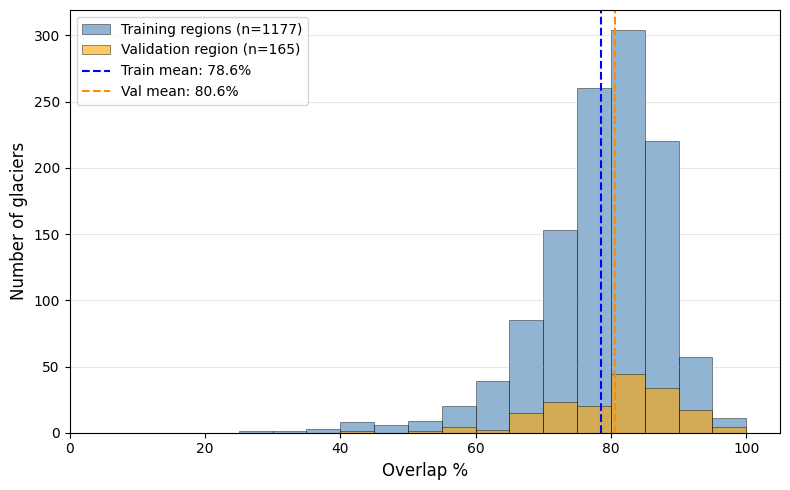

In [8]:
fig = plot_overlap_histogram(
    df_overlap,
    df[["rgi_id", "region"]].drop_duplicates(subset="rgi_id"),
    val_region=VALIDATION_REGION,
)
fig.savefig(OUTPUT_DIR / "overlap_histogram.png", dpi=200, bbox_inches="tight")
plt.show()

## Vulnerability ranking and physical characteristics

Ranks all glaciers by mean MLP predicted melt probability, then compares
physical characteristics (elevation, slope, aspect, edge distance, area)
between the most and least vulnerable quartiles.

**Note:** the predictions parquet only retains `edge_distance` among the
EASD features. Elevation, slope, and aspect are loaded separately from
the `Training_Data_2017` parquets and joined in by RGI glacier ID, since
those columns were not carried into the predictions file.

In [9]:
df_train = load_parquet_regions(TRAINING_DIR)
df_train["rgi_id"] = assign_pixels_to_glaciers(df_train, rgi_gdf)

df_physical = glacier_physical_features(df_train)
df_physical.head()

r1a: 6,222,913 pixels, 1.86 GB
r1b: 1,028,089 pixels, 0.31 GB
r2: 6,217,318 pixels, 1.85 GB
r3: 1,774,319 pixels, 0.53 GB

Combined: 15,242,639 pixels
Memory: 4.55 GB
Melt rate: 19.50%


,rgi_id,mean_elevation,mean_slope,mean_aspect,mean_edge_dist
0,RGI2000-v7.0-G-16-00116,4926.182617,28.779806,184.250275,43.069969
1,RGI2000-v7.0-G-16-00118,4926.079102,27.087420,214.407257,40.304642
2,RGI2000-v7.0-G-16-00119,4970.349121,31.710743,242.913223,49.856686
3,RGI2000-v7.0-G-16-00120,4978.320801,26.569824,142.961472,35.997242
4,RGI2000-v7.0-G-16-00121,4947.425293,34.388062,296.320892,28.411793


In [10]:
df_vuln = vulnerability_ranking(df, df[MLP_COL].values)
df_vuln = df_vuln.merge(df_physical, on="rgi_id", how="inner")
df_vuln.to_parquet(OUTPUT_DIR / "vulnerability_ranking.parquet", index=False)

df_vuln.head(10)

,rgi_id,mean_mlp_score,n_pixels,area_km2,vulnerability_rank,mean_elevation,mean_slope,mean_aspect,mean_edge_dist
0,RGI2000-v7.0-G-16-01724,0.999793,11,0.0011,1,4845.454590,15.272727,166.454544,10.262383
1,RGI2000-v7.0-G-16-02662,0.999715,72,0.0072,2,5200.958496,27.781250,231.177078,12.235911
2,RGI2000-v7.0-G-16-02376,0.999680,74,0.0074,3,5139.756836,29.027027,200.216217,17.019306
3,RGI2000-v7.0-G-16-02635,0.999649,7,0.0007,4,5272.000000,19.571428,195.714279,13.178399
4,RGI2000-v7.0-G-16-01306,0.999603,6,0.0006,5,4737.500000,37.833332,279.333344,9.797360
5,RGI2000-v7.0-G-16-02371,0.999601,9,0.0009,6,5169.777832,32.111111,208.000000,10.203401
6,RGI2000-v7.0-G-16-02360,0.999597,51,0.0051,7,5256.627441,27.882353,184.549026,12.319153
7,RGI2000-v7.0-G-16-02362,0.999441,14,0.0014,8,5283.143066,24.714285,189.428574,9.695157
8,RGI2000-v7.0-G-16-01726,0.999440,155,0.0155,9,4717.509766,33.845161,192.219360,14.446749
9,RGI2000-v7.0-G-16-02572,0.999310,6,0.0006,10,5282.500000,22.833334,160.333328,9.644909


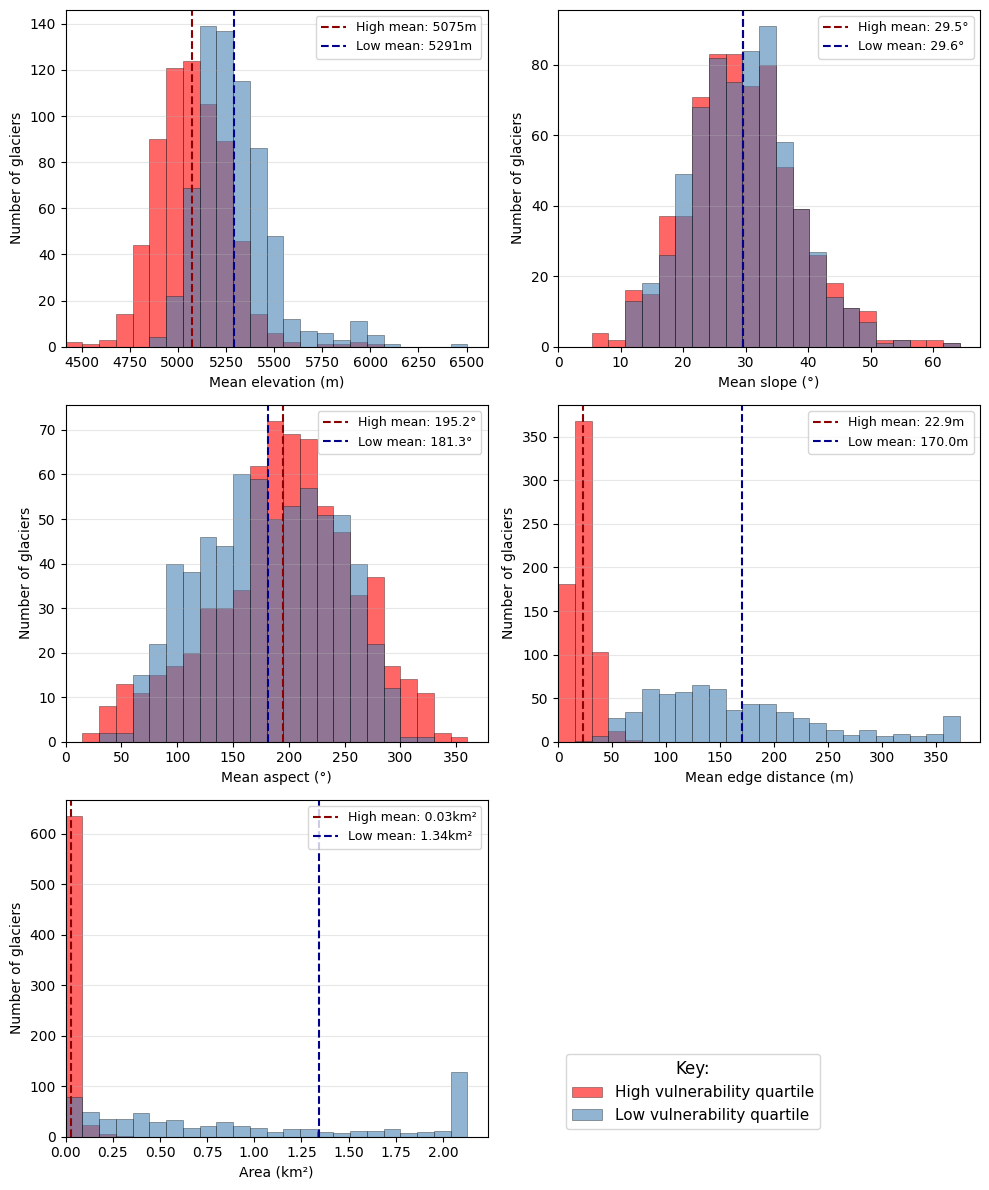

In [11]:
fig = plot_vulnerability_characteristics(df_vuln)
fig.savefig(OUTPUT_DIR / "vulnerability_characteristics.png", dpi=200, bbox_inches="tight")
plt.show()